# VLM Filtering and Captioning Testbed

This notebook serves as a testbed for the Stage 1 (Reference Filtering) and Stage 2 (Variation Filtering / Captioning) pipeline on local images, utilizing product metadata loaded by ASIN.

### 1. Imports and Setup

In [1]:
import os
import json
import re
import torch
from PIL import Image
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForCausalLM

try:
    from transformers import Qwen3VLForConditionalGeneration
except ImportError:
    Qwen3VLForConditionalGeneration = None

# Set inference/generation configurations as environment variables
os.environ["greedy"] = "false"
os.environ["top_p"] = "0.8"
os.environ["top_k"] = "20"
os.environ["temperature"] = "0.7"
os.environ["repetition_penalty"] = "1.0"
os.environ["presence_penalty"] = "1.5"
os.environ["out_seq_length"] = "16384"

/root/Desktop/workspace/woosung/AMZN-review-2023/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Loading Product Metadata from Hugging Face by ASIN

In [2]:
asin = "B089Q52C3Z"
category_name = "raw_meta_Amazon_Fashion"

print(f"Searching metadata for category '{category_name}' and ASIN '{asin}'...")
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", category_name, trust_remote_code=True, split="full", streaming=True)

product_title = None
product_row = None
for row in dataset:
    if row.get('parent_asin') == asin:
        product_title = row.get('title')
        product_row = row
        print(f"\nSuccess! Found product info:")
        print(f"ASIN: {asin}")
        print(f"Title: {product_title}")
        break

if not product_title:
    product_title = "Fleece Blanket Throw Blanket Super Soft Warm Blanket for Couch Bed Sofa"
    print(f"\nASIN not found in dataset stream. Using default fallback title: {product_title}")

Searching metadata for category 'raw_meta_Amazon_Fashion' and ASIN 'B089Q52C3Z'...

Success! Found product info:
ASIN: B089Q52C3Z
Title: AEONSLOVE I Love You Necklace 100 Languages Projection 925 Sterling Silver Infinity Heart Pendant Love Necklaces Jewellery for Girlfriend Women Wife Girls Birthday Anniversary Romantic Gifts for Her


### 3. Setup Paths and Load Prompts / Local Images

In [3]:
workspace_dir = "/root/Desktop/workspace/woosung/AMZN-review-2023"
ref_image_path = os.path.join(workspace_dir, "detail_benchmark", category_name, asin, "reference.jpg")

variation_images = [
    os.path.join(workspace_dir, "detail_benchmark", category_name, asin, f"variation_{i}.jpg")
    for i in range(1, 4)
]

print(f"Reference image path: {ref_image_path} (Exists: {os.path.exists(ref_image_path)})")
for idx, path in enumerate(variation_images, 1):
    print(f"Variation {idx} path: {path} (Exists: {os.path.exists(path)})")

# Load prompts
with open(os.path.join(workspace_dir, "lib", "reference_filtering_instruction.txt"), "r") as f:
    reference_filtering_instruction = f.read().strip()

with open(os.path.join(workspace_dir, "lib", "variation_filtering_instruction.txt"), "r") as f:
    variation_prompt = f.read().strip()

print("\nPrompts loaded successfully!")

Reference image path: /root/Desktop/workspace/woosung/AMZN-review-2023/detail_benchmark/raw_meta_Amazon_Fashion/B089Q52C3Z/reference.jpg (Exists: True)
Variation 1 path: /root/Desktop/workspace/woosung/AMZN-review-2023/detail_benchmark/raw_meta_Amazon_Fashion/B089Q52C3Z/variation_1.jpg (Exists: True)
Variation 2 path: /root/Desktop/workspace/woosung/AMZN-review-2023/detail_benchmark/raw_meta_Amazon_Fashion/B089Q52C3Z/variation_2.jpg (Exists: True)
Variation 3 path: /root/Desktop/workspace/woosung/AMZN-review-2023/detail_benchmark/raw_meta_Amazon_Fashion/B089Q52C3Z/variation_3.jpg (Exists: True)

Prompts loaded successfully!


### 4. Display Images

=== Reference Image ===


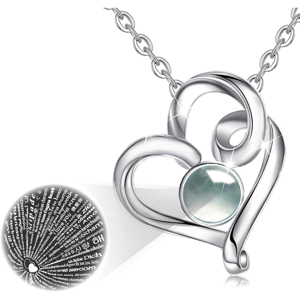

=== Variation 1 Image ===


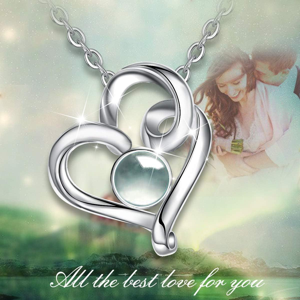

=== Variation 2 Image ===


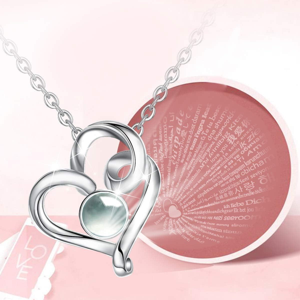

=== Variation 3 Image ===


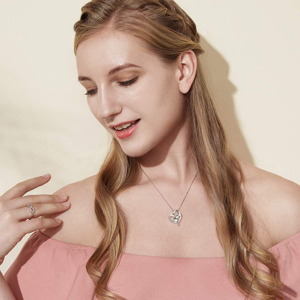

In [4]:
from IPython.display import display

print("=== Reference Image ===")
display(Image.open(ref_image_path).resize((300, 300)))

for idx, path in enumerate(variation_images, 1):
    if os.path.exists(path):
        print(f"=== Variation {idx} Image ===")
        display(Image.open(path).resize((300, 300)))

### 5. Helper Functions

In [8]:
def make_square_image(image, fill_color=(255, 255, 255)):
    width, height = image.size
    if width == height:
        return image
    elif width > height:
        new_image = Image.new("RGB", (width, width), fill_color)
        top_offset = (width - height) // 2
        new_image.paste(image, (0, top_offset))
        return new_image
    else:
        new_image = Image.new("RGB", (height, height), fill_color)
        left_offset = (height - width) // 2
        new_image.paste(image, (left_offset, 0))
        return new_image

def generate_with_vlm(messages, model, processor, max_new_tokens=256):
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt"
    )
    inputs = inputs.to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

def parse_json_response(response_str):
    try:
        cleaned = response_str.strip()
        if cleaned.startswith("```json"):
            cleaned = cleaned[7:]
        if cleaned.endswith("```"):
            cleaned = cleaned[:-3]
        cleaned = cleaned.strip()

        start = cleaned.find('{')
        end = cleaned.rfind('}')
        if start != -1 and end != -1:
            cleaned = cleaned[start:end+1]

        return json.loads(cleaned)
    except Exception as e:
        print(f"Error parsing VLM response as JSON: {e}\nResponse: {response_str}")
        return {}

### 6. Initialize VLM Model (Qwen/Qwen3-VL-32B-Instruct)

In [10]:
print("=== Loading VLM Model ===")
model_name = "Qwen/Qwen3-VL-32B-Instruct"
GPU = "cuda:1"
processor = AutoProcessor.from_pretrained(model_name)

try:
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.bfloat16, device_map=GPU, trust_remote_code=True
    )
except Exception as e:
    print("Fallback model loading...")
    if Qwen3VLForConditionalGeneration is not None:
        model = Qwen3VLForConditionalGeneration.from_pretrained(
            model_name, torch_dtype=torch.bfloat16, device_map=GPU, trust_remote_code=True
        )
    else:
        raise e

print("Model loaded successfully!")

=== Loading VLM Model ===
Fallback model loading...


Loading weights: 100%|██████████| 1058/1058 [00:13<00:00, 77.95it/s] 


Model loaded successfully!


### 7. Run Stage 1: Reference Filtering

In [11]:
# Load prompts
with open(os.path.join(workspace_dir, "lib", "reference_filtering_instruction.txt"), "r") as f:
    reference_filtering_instruction = f.read().strip()

with open(os.path.join(workspace_dir, "lib", "variation_filtering_instruction.txt"), "r") as f:
    variation_prompt = f.read().strip()

print("\nPrompts loaded successfully!")


Prompts loaded successfully!


In [12]:
print("=== Running Stage 1: Reference Filtering ===")
ref_img = Image.open(ref_image_path).convert("RGB")
ref_square = make_square_image(ref_img)

tmp_ref_path = os.path.join(workspace_dir, "tmp_notebook_ref.jpg")
ref_square.save(tmp_ref_path)

messages_detail = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": reference_filtering_instruction},
            {"type": "text", "text": f"Product Name: {product_title}"},
            {"type": "image", "image": f"{tmp_ref_path}"},
        ]
    }
]

content_reference_raw = generate_with_vlm(messages_detail, model, processor, max_new_tokens=256)
content_reference = parse_json_response(content_reference_raw)

print("--- Raw Response ---")
print(content_reference_raw)
print("\n--- Parsed JSON ---")
print(json.dumps(content_reference, indent=4))

=== Running Stage 1: Reference Filtering ===
--- Raw Response ---
{
  "isolation": "PASS",
  "detail_richness": "PASS",
  "decision": "ACCEPT"
}

--- Parsed JSON ---
{
    "isolation": "PASS",
    "detail_richness": "PASS",
    "decision": "ACCEPT"
}


### 8. Run Stage 2: Variation Filtering & Prompt Extraction

In [ ]:
print("=== Running Stage 2: Variation Filtering & Prompt Extraction ===")

for idx, var_img_path in enumerate(variation_images, 1):
    if not os.path.exists(var_img_path):
        continue

    print(f"\n========================================")
    print(f"Testing Variation {idx}: {os.path.basename(var_img_path)}")
    print(f"========================================")

    var_img = Image.open(var_img_path).convert("RGB")
    tmp_var_path = os.path.join(workspace_dir, f"tmp_notebook_var_{idx}.jpg")
    var_img.save(tmp_var_path)

    messages_var = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": f"{tmp_ref_path}"},
                {"type": "image", "image": f"{tmp_var_path}"},
                {"type": "text", "text": variation_prompt}
            ]
        }
    ]

    content_var_raw = generate_with_vlm(messages_var, model, processor, max_new_tokens=256)
    content_var = parse_json_response(content_var_raw)

    print("--- Stage 2 Decision Output ---")
    print(json.dumps(content_var, indent=4))

    if content_var.get("decision") == "ACCEPT":
        # Category inference
        cat_prompt = (
            f"Given the product title \"{product_title}\" and the product image, "
            "what is the specific generic categorical name of the product (e.g. 'keyboard switch', 'earrings', 'watchband', 'tote bag', 'electric lighter')? "
            "Respond with ONLY the category name (1-3 words) in lowercase, without punctuation or articles."
        )
        messages_cat = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": f"{tmp_ref_path}"},
                    {"type": "text", "text": cat_prompt}
                ]
            }
        ]
        categorical_name = generate_with_vlm(messages_cat, model, processor, max_new_tokens=15).strip().lower()
        categorical_name = re.sub(r'[^a-z0-9\s-]', '', categorical_name).strip()
        if not categorical_name:
            categorical_name = "product"
        print(f"\nInferred Categorical Name: {categorical_name}")

        # Prompt Extraction
        prompt_query = (
            "You are an expert in writing prompts for Subject Driven Image Generation (like DreamBooth, Flux-ControlNet, etc.).\n"
            f"Given a reference image of the product (Image 1) and a target advertisement/infographic image (Image 2), "
            f"write a text prompt describing the target image (Image 2) so a generative model can reproduce its style and layout with a custom subject.\n\n"
            "Rules:\n"
            f"1. Use the generic class name 'the {categorical_name}' (or 'the product') for the subject instead of brand-specific names.\n"
            f"2. Do NOT describe the intrinsic visual properties of the product itself (such as its specific colors, original brand logo printings, or specific text/labels printed directly on the product's body). Never use phrases like 'with its original design and branding visible' or 'showing its original design'. Leave the subject's visual appearance completely undescribed, as those details must come solely from the custom subject itself.\n"
            f"3. CRITICAL: Completely ignore and omit any text, words, headlines, slogans, numbers, disclaimers, or copies present in Image 2. Do NOT describe them, do NOT quote them, and do NOT describe placeholder shapes like blank boxes or outlines representing text. Describe the background and panels simply as solid-colored, plain, or empty (e.g. 'a solid yellow background panel', 'a plain white background', 'a solid peach-pink background'). All text and placeholder elements must be completely ignored as if they do not exist, leaving the layout clean, plain, and natural.\n"
            f"4. Describe the layout, environment, lighting, action, and main external graphic/color panels precisely (e.g. 'A split-screen layout...', 'A product shot on a plain background...').\n"
            f"5. Keep the description natural, clear, and direct. Do NOT start with 'The target image...' or 'In Image 2...'. Describe the image layout and content directly."
        )
        messages_prompt = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": f"{tmp_ref_path}"},
                    {"type": "image", "image": f"{tmp_var_path}"},
                    {"type": "text", "text": prompt_query}
                ]
            }
        ]
        variation_prompt_str = generate_with_vlm(messages_prompt, model, processor, max_new_tokens=150).strip()
        print(f"\nGenerated Subject-Driven Generation Prompt:\n{variation_prompt_str}")


In [16]:
var_img_path = variation_images[0]
categorical_name = "necklace"

print(f"\n========================================")
print(f"Testing Variation : {os.path.basename(var_img_path)}")
print(f"========================================")

var_img = Image.open(var_img_path).convert("RGB")
tmp_var_path = os.path.join(workspace_dir, f"tmp_notebook_var_{idx}.jpg")
var_img.save(tmp_var_path)

# Prompt Extraction
prompt_query = (
	"You are an expert in writing prompts for Subject Driven Image Generation (like DreamBooth, Flux-ControlNet, etc.).\n"
	f"Given a reference image of the product (Image 1) and a target advertisement/infographic image (Image 2), "
	f"write a text prompt describing the target image (Image 2) so a generative model can reproduce its style and layout with a custom subject.\n\n"
	"Rules:\n"
	f"1. Use the generic class name 'the {categorical_name}' (or 'the product') for the subject instead of brand-specific names.\n"
	f"2. Do NOT describe the intrinsic visual properties of the product itself (such as its specific colors, original brand logo printings, or specific text/labels printed directly on the product's body). Never use phrases like 'with its original design and branding visible' or 'showing its original design'. Leave the subject's visual appearance completely undescribed, as those details must come solely from the custom subject itself.\n"
	f"3. CRITICAL: Completely ignore and omit any text, words, headlines, slogans, numbers, disclaimers, or copies present in Image 2. Do NOT describe them, do NOT quote them, and do NOT describe placeholder shapes like blank boxes or outlines representing text. Describe the background and panels simply as solid-colored, plain, or empty (e.g. 'a solid yellow background panel', 'a plain white background', 'a solid peach-pink background'). All text and placeholder elements must be completely ignored as if they do not exist, leaving the layout clean, plain, and natural.\n"
	f"4. Describe the layout, environment, lighting, action, and main external graphic/color panels precisely (e.g. 'A split-screen layout...', 'A product shot on a plain background...').\n"
	f"5. Keep the description natural, clear, and direct. Do NOT start with 'The target image...' or 'In Image 2...'. Describe the image layout and content directly."
)
messages_prompt = [
	{
		"role": "user",
		"content": [
			{"type": "image", "image": f"{tmp_ref_path}"},
			{"type": "image", "image": f"{tmp_var_path}"},
			{"type": "text", "text": prompt_query}
		]
	}
]
variation_prompt_str = generate_with_vlm(messages_prompt, model, processor, max_new_tokens=150).strip()
print(f"\nGenerated Subject-Driven Generation Prompt:\n{variation_prompt_str}")



Testing Variation : variation_1.jpg

Generated Subject-Driven Generation Prompt:
A split-screen composition featuring the necklace prominently on the left side, set against a soft, dreamy background with a gentle gradient of pale green and light blue hues, accented with subtle bokeh and sparkling light effects. The necklace is positioned slightly diagonally, with its chain extending upward toward the top corners, and is rendered with high reflectivity and bright highlights to emphasize its polished metallic surface. On the right side of the image, a softly blurred, romantic scene depicts a couple in an intimate embrace, with the woman smiling gently and the man resting his head near her shoulder; the couple is semi-transparent and blended into the background, creating a layered, ethereal effect. The overall lighting is soft and diffused, with a warm glow emanating
